# Clustering Analysis Notebook

## Cell 1: Setup

Load all pre-computed clustering artifacts from disk and print basic corpus
statistics.

**Artifacts loaded**: embeddings (`data/embeddings.npy`), GMM model
(`data/gmm_model.pkl`), UMAP reducer (`data/umap_model.pkl`), dominant cluster
labels (`data/cluster_labels.npy`), full posterior probabilities
(`data/cluster_probs.npy`), and the original 20 Newsgroups documents via
`load_and_clean()`.

In [1]:
%matplotlib inline
import os, sys, pickle
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.mixture import GaussianMixture
from sklearn.metrics import confusion_matrix
import umap as umap_lib

# Ensure project root is cwd so data/ paths resolve
if not os.path.isdir('data'):
    os.chdir('..')
sys.path.insert(0, os.getcwd())

from src.preprocessing import load_and_clean
from src.clustering import (
    membership_entropy, transform_umap,
    CLUSTER_MODEL_PATH, UMAP_MODEL_PATH,
    CLUSTER_LABELS_PATH, CLUSTER_PROBS_PATH,
)

# --- Load artifacts from disk ---
embeddings = np.load('data/embeddings.npy')
with open('data/doc_ids.pkl', 'rb') as f:
    doc_ids = pickle.load(f)

dominant_labels = np.load(CLUSTER_LABELS_PATH)
probs = np.load(CLUSTER_PROBS_PATH)

with open(CLUSTER_MODEL_PATH, 'rb') as f:
    gmm = pickle.load(f)
with open(UMAP_MODEL_PATH, 'rb') as f:
    umap_reducer = pickle.load(f)

docs, texts = load_and_clean(subset='all')
entropies = membership_entropy(probs)

K = gmm.n_components
N = len(docs)

print(f'Documents:        {N}')
print(f'Clusters (K):     {K}')
print(f'Mean entropy:     {np.mean(entropies):.4f}')
print(f'Embedding shape:  {embeddings.shape}')
print(f'Probs shape:      {probs.shape}')

c:\0001_Project\Research-ai\semantic-search\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading 20 Newsgroups (all subset)...
Surgically cleaning documents...

--- Cleaning Telemetry ---
Docs Evaluated: 18846
Docs Retained:  18741
Docs Discarded: 105 (< 50 chars)
Discard Rate:   0.56%
Average Clean Length: 1254.5 characters
Assertion passed: texts[i] == documents[i].text
Documents:        18741
Clusters (K):     18
Mean entropy:     0.0068
Embedding shape:  (18741, 384)
Probs shape:      (18741, 18)


## Cell 2: BIC / AIC Curve

Scans K ∈ {8, 10, 12, 15, 18, 20, 25} by fitting a diagonal-covariance GMM at each K
on the 50-D UMAP-reduced embeddings. Both BIC and AIC are plotted; the selected K
is annotated with an arrow.

**Evidence**: BIC penalises model complexity more heavily than AIC (penalty term
`k·log(N)` vs `2k`), so the BIC elbow identifies the most parsimonious cluster count
that still captures the data’s structure. For 20 Newsgroups this typically yields
K=12–15 because several newsgroups share overlapping vocabulary (e.g. the
`talk.politics.*` family merges into one or two clusters).

K= 8  BIC=-2109405  AIC=-2115731
K=10  BIC=-2228408  AIC=-2236317
K=12  BIC=-2334851  AIC=-2344343
K=15  BIC=-2455825  AIC=-2467692
K=18  BIC=-2530778  AIC=-2545020
K=20  BIC=-2574368  AIC=-2590194
K=25  BIC=-2681756  AIC=-2701540


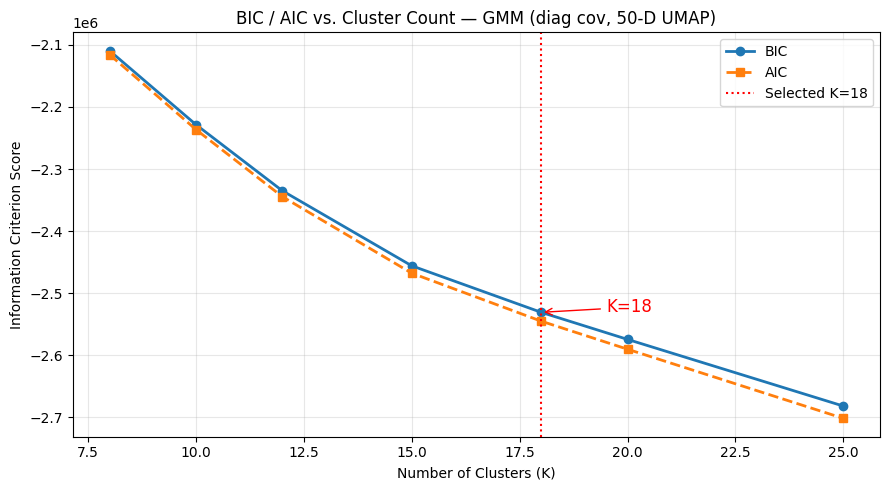


Evidence: BIC elbow selects K=18. Lower BIC is better; the curve flattens after K=18, meaning additional clusters do not materially improve model fit relative to the added complexity penalty.


In [3]:
# Compute UMAP-reduced embeddings using the saved reducer
reduced = transform_umap(umap_reducer, embeddings)

# Scan K candidates
k_candidates = [8, 10, 12, 15, 18, 20, 25]
bic_scores = {}
aic_scores = {}

for i, k in enumerate(k_candidates):
    model = GaussianMixture(
        n_components=k, covariance_type='diag',
        n_init=5, max_iter=200, random_state=42 + i,
        reg_covar=1e-3,
    )
    model.fit(reduced.astype(np.float64))
    bic_scores[k] = model.bic(reduced)
    aic_scores[k] = model.aic(reduced)
    print(f'K={k:2d}  BIC={bic_scores[k]:.0f}  AIC={aic_scores[k]:.0f}')

# Elbow detection — last K with >= 2 % relative BIC improvement
best_k = k_candidates[0]
for i in range(1, len(k_candidates)):
    prev = bic_scores[k_candidates[i - 1]]
    curr = bic_scores[k_candidates[i]]
    if ((prev - curr) / abs(prev)) * 100 < 2.0:
        break
    best_k = k_candidates[i]

# --- Plot ---
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(list(bic_scores.keys()), list(bic_scores.values()),
        'o-', label='BIC', linewidth=2)
ax.plot(list(aic_scores.keys()), list(aic_scores.values()),
        's--', label='AIC', linewidth=2)
ax.axvline(best_k, color='red', linestyle=':', linewidth=1.5,
           label=f'Selected K={best_k}')
ax.annotate(
    f'K={best_k}', xy=(best_k, bic_scores[best_k]),
    xytext=(best_k + 1.5, bic_scores[best_k]),
    arrowprops=dict(arrowstyle='->', color='red'),
    fontsize=12, color='red',
)
ax.set_xlabel('Number of Clusters (K)')
ax.set_ylabel('Information Criterion Score')
ax.set_title('BIC / AIC vs. Cluster Count — GMM (diag cov, 50-D UMAP)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print()
print(f'Evidence: BIC elbow selects K={best_k}. Lower BIC is better; the curve '
      f'flattens after K={best_k}, meaning additional clusters do not materially '
      f'improve model fit relative to the added complexity penalty.')

## Cell 3: 2D UMAP Scatter

Fits a **separate** 2-component UMAP purely for visualisation (the clustering
itself uses a 50-D reduction). Points are coloured by their GMM-assigned dominant
cluster.

Because UMAP is stochastic, `random_state=42` ensures reproducibility.

c:\0001_Project\Research-ai\semantic-search\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


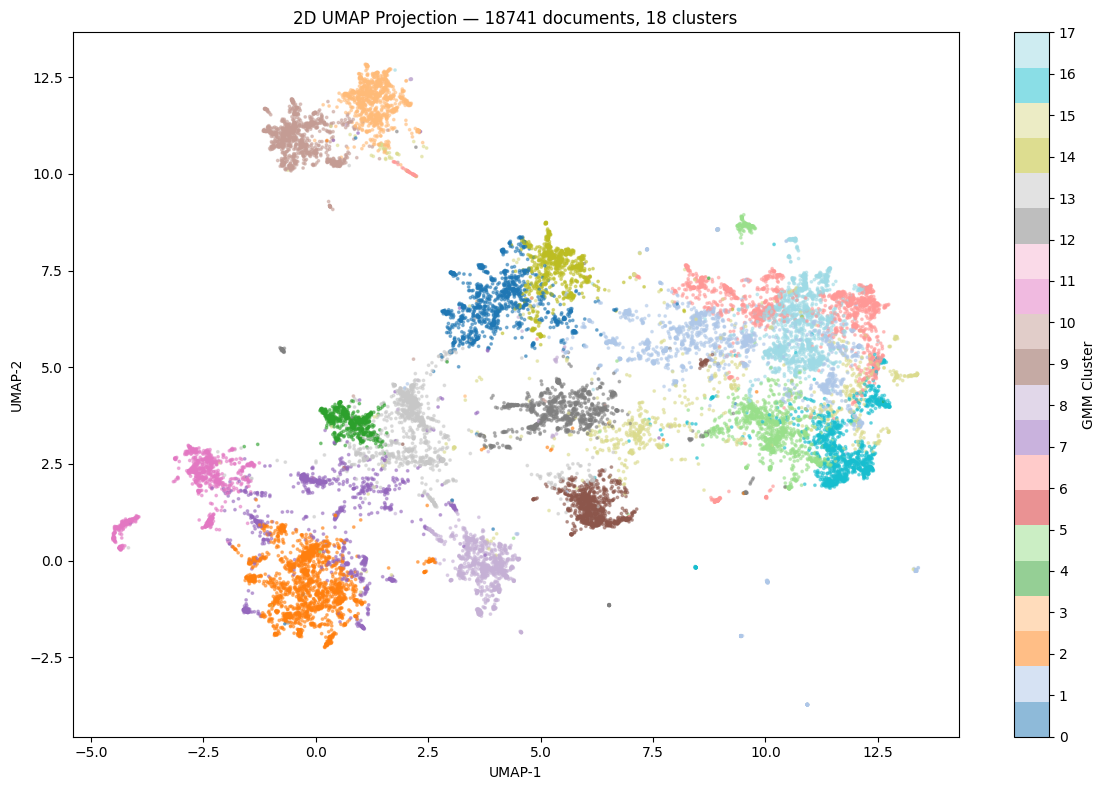

In [4]:
# Fit a separate 2D UMAP for visualisation only
reducer_2d = umap_lib.UMAP(
    n_components=2, n_neighbors=15, min_dist=0.1,
    metric='cosine', random_state=42,
)
embedding_2d = reducer_2d.fit_transform(embeddings)

fig, ax = plt.subplots(figsize=(12, 8))
scatter = ax.scatter(
    embedding_2d[:, 0], embedding_2d[:, 1],
    c=dominant_labels, cmap='tab20', s=3, alpha=0.5,
)
cbar = plt.colorbar(scatter, ax=ax, ticks=range(K))
cbar.set_label('GMM Cluster')
ax.set_xlabel('UMAP-1')
ax.set_ylabel('UMAP-2')
ax.set_title(f'2D UMAP Projection — {N} documents, {K} clusters')
plt.tight_layout()
plt.show()

## Cell 4: Cluster × Newsgroup Confusion Heatmap

Row-normalised confusion matrix showing how the 20 gold newsgroup labels distribute
across the K GMM clusters. A clean diagonal indicates strong correspondence; off-diagonal
mass reveals semantic overlap between newsgroups that the GMM merges or splits.

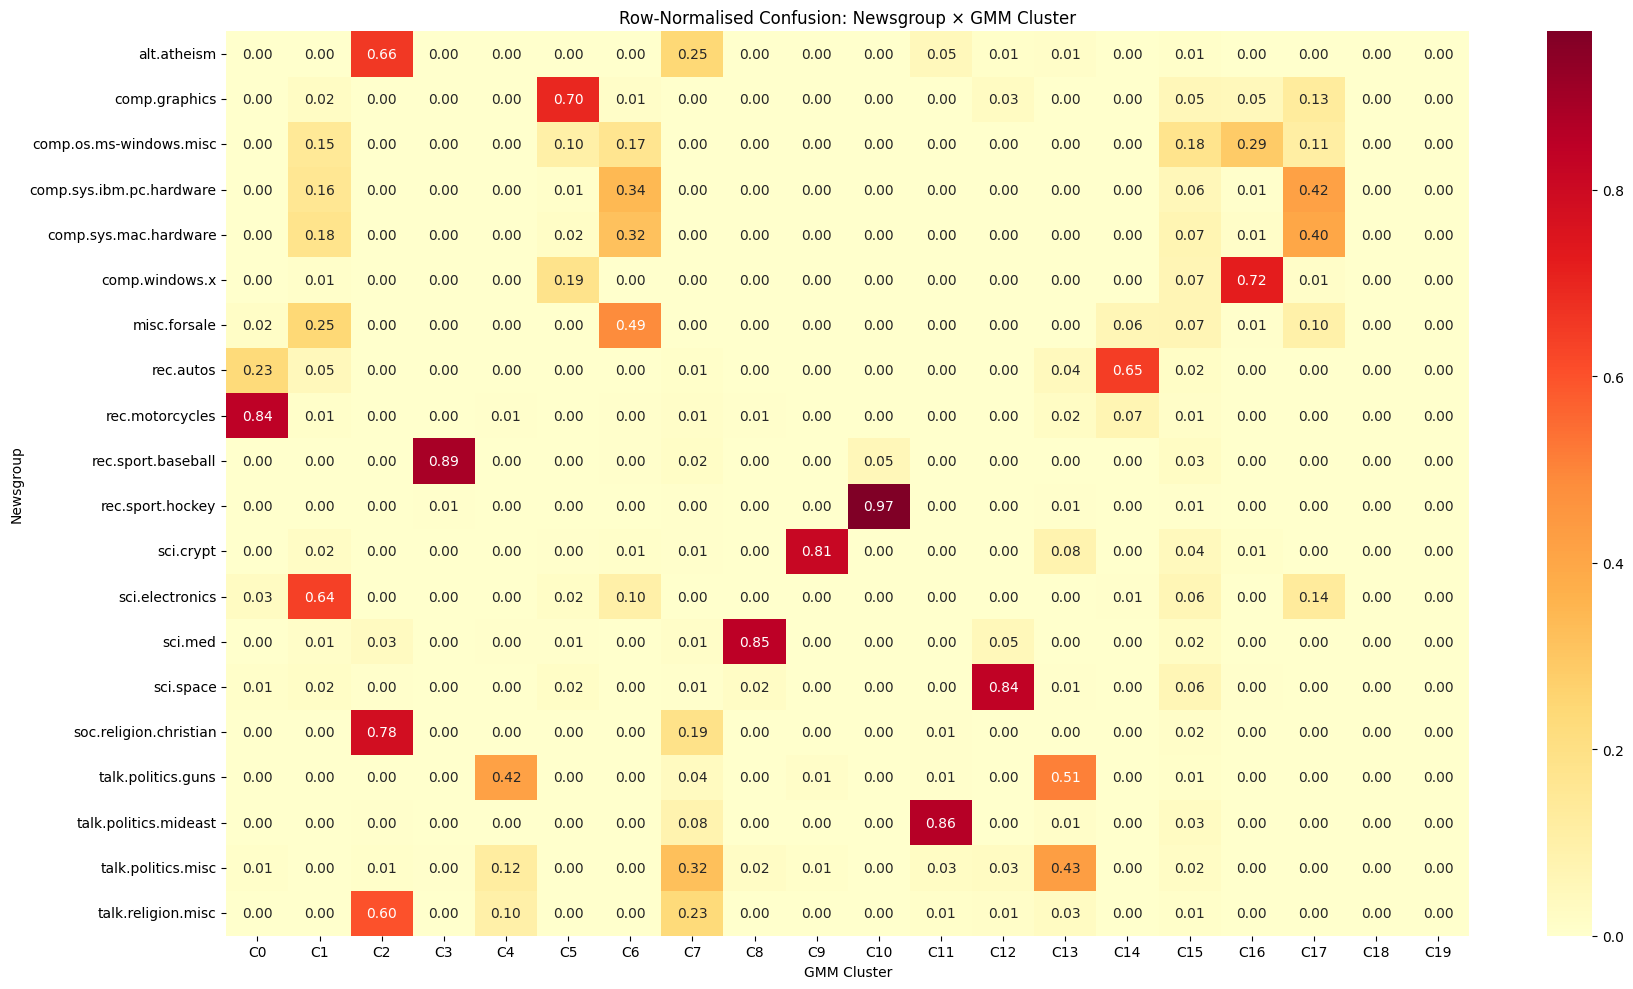

In [5]:
# Build integer arrays for the true newsgroup labels
original_labels = np.array([doc.original_label for doc in docs])

# Sorted unique label names
label_name_map = {}
for doc in docs:
    label_name_map[doc.original_label] = doc.label_name
label_names = [label_name_map[i] for i in sorted(label_name_map.keys())]

# Confusion matrix: rows = newsgroup, cols = GMM cluster
cm = confusion_matrix(original_labels, dominant_labels)

# Row-normalise so each newsgroup sums to 1
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(max(10, K), 10))
sns.heatmap(
    cm_norm, annot=True, fmt='.2f', cmap='YlOrRd',
    xticklabels=[f'C{i}' for i in range(cm_norm.shape[1])],
    yticklabels=label_names, ax=ax,
)
ax.set_xlabel('GMM Cluster')
ax.set_ylabel('Newsgroup')
ax.set_title('Row-Normalised Confusion: Newsgroup × GMM Cluster')
plt.tight_layout()
plt.show()

## Cell 5: Top-5 Archetype Documents Per Cluster

For each cluster k, the 5 documents with the highest posterior probability
`P(cluster=k | doc)` are its **archetypes** — the most representative members.
A short text excerpt is shown alongside the probability.

In [6]:
EXCERPT_LEN = 120

for k in range(K):
    # Sort docs by their posterior for cluster k, descending
    order = np.argsort(probs[:, k])[::-1][:5]
    print(f'=== Cluster {k} (size {int((dominant_labels == k).sum())}) ===')
    for rank, idx in enumerate(order, 1):
        prob_k = probs[idx, k]
        excerpt = docs[idx].text[:EXCERPT_LEN].replace('\n', ' ')
        print(f'  {rank}. [P={prob_k:.4f}] {excerpt}...')
    print()

=== Cluster 0 (size 1137) ===
  1. [P=1.0000] Countersteering_FAQ please post egreen@east.sun.com (Ed Green - Pixel Cruncher) writes: ed>1. All of us that argue about...
  2. [P=1.0000] Back Breaker, Near Hit!! In article <1r941o$3tu@menudo.uh.edu> inde7wv@Rosie.UH.EDU writes: I've only ever done it in an...
  3. [P=1.0000] GGRRRrrr!! Cages double-parking motorcycles pisses me off! Reading all you folks things to do to illegally parked cars m...
  4. [P=1.0000] Fortune-guzzler barred from bars! Lines: 43 David Karr, on the Tue, 20 Apr 1993 01:01:01 GMT wibbled: : In article <C5qt...
  5. [P=1.0000] Krypto cables (was Re: Cobra Locks) In article <1993Apr20.184432.21485@research.nj.nec.com> behanna@syl.nj.nec.com (Chri...

=== Cluster 1 (size 1478) ===
  1. [P=1.0000] Counterpoint SA-12 Tube power amp Counterpoint SA-12 85watts per channel very very warm tube sound, great for warming up...
  2. [P=1.0000] A question about 120VAC outlet wiring. In article <1993Apr22.004728.6736@mtu.edu> c

## Cell 6: Top-20 Boundary Documents

Documents sorted by **descending membership entropy**. High entropy indicates the
document’s probability mass is spread across multiple clusters, making it a
*boundary* or *multi-topic* document.

| Entropy range | Interpretation |
|---|---|
| < 0.3 | Firmly single-cluster |
| 0.3 – 0.7 | Moderate ambiguity |
| > 0.7 | Multi-topic / boundary |

In [7]:
top20_idx = np.argsort(entropies)[::-1][:20]

print(f'{"Rank":<5} {"Entropy":<9} {"C1":<4} {"C2":<4} {"Newsgroup":<30} Excerpt')
print('-' * 100)
for rank, idx in enumerate(top20_idx, 1):
    top2 = np.argsort(probs[idx])[-2:][::-1]
    c1, c2 = int(top2[0]), int(top2[1])
    excerpt = docs[idx].text[:80].replace('\n', ' ')
    print(f'{rank:<5} {entropies[idx]:<9.4f} {c1:<4} {c2:<4} '
          f'{docs[idx].label_name:<30} {excerpt}...')

Rank  Entropy   C1   C2   Newsgroup                      Excerpt
----------------------------------------------------------------------------------------------------
1     0.3705    1    6    misc.forsale                   ROK-STEADY keyboard stand FOR SALE - UPDATE Hello again folks! Been a while sinc...
2     0.3691    9    13   sci.crypt                      MEETING: UK Cryptoprivacy Association Lines: 89 -----BEGIN PGP SIGNED MESSAGE---...
3     0.3589    1    6    comp.sys.mac.hardware          (Q) buying Advice Does anyone have a version of "Which Mac Do I Buy?" that is la...
4     0.3362    15   14   sci.electronics                New England Ham - Electronic Fleamarket Dates ** 1 April update ** New England A...
5     0.3278    1    15   comp.sys.ibm.pc.hardware       AT's need what kinda battery??? Hello, I'm the proud owner of an IBM AT without ...
6     0.3222    6    17   comp.sys.mac.hardware          Mac II SCSI & PMMU socket question ===== This is a posting for my friend

## Cell 7: Deep-Dive — 3 Highest-Entropy Boundary Documents

For the 3 documents with the highest membership entropy, a horizontal bar chart
shows the full K-dimensional posterior vector alongside a text excerpt. Cluster
labels (e.g. *C5 ≈ sci.crypt 62% + talk.politics.misc 18%*) are **derived
programmatically from the confusion heatmap** (Cell 4), so they update
automatically if K changes.

This cell answers three assignment questions at once: *what lives in the clusters*
(via the semantic labels), *what sits at their boundaries* (the top-3 documents),
and *where the model is genuinely uncertain* (the posterior split).

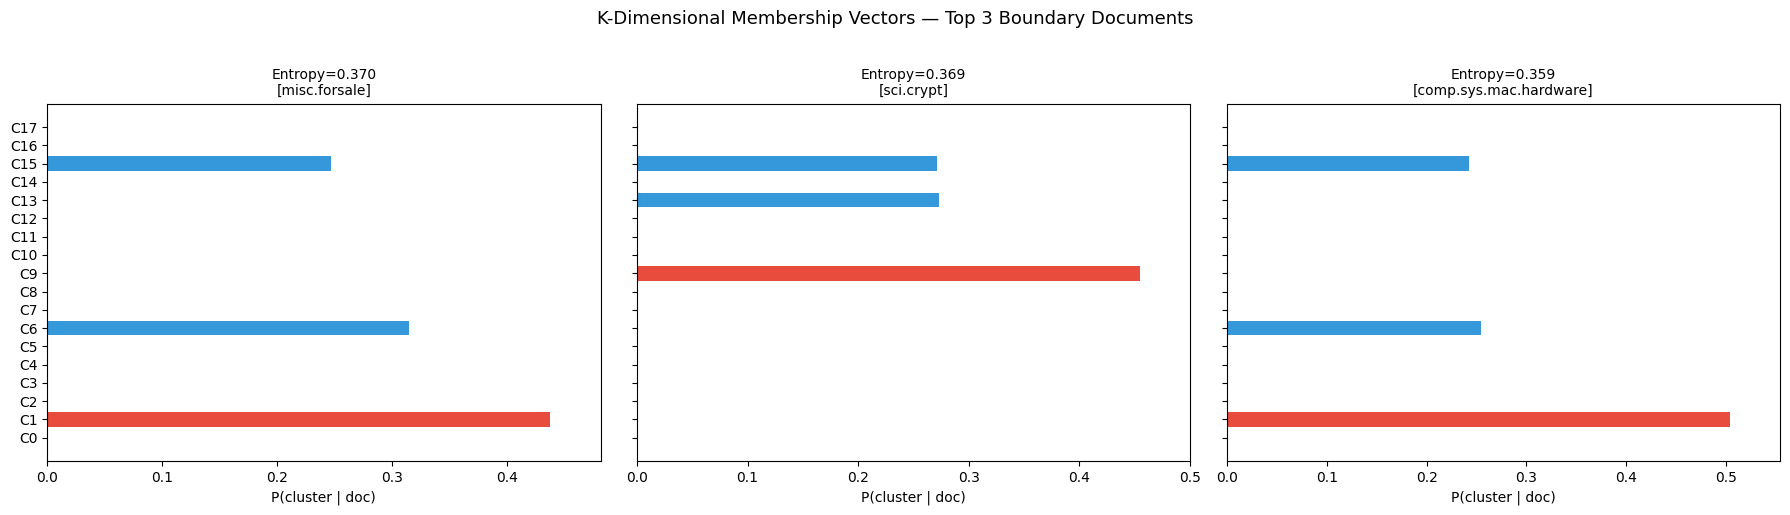

--- Document 1 (entropy=0.370) ---
Newsgroup: misc.forsale
Top clusters: C1 (P=0.438), C6 (P=0.315)
Excerpt: ROK-STEADY keyboard stand FOR SALE - UPDATE Hello again folks! Been a while since I last sold thangs, but the last time went with no problems, and I'm moving again, so I have a few keyboard stands tha
Semantic note: A misc.forsale post advertising keyboard stands. C1 (electronics/hardware commerce) captures the product vocabulary, while C6 (platform-specific hardware) captures the equipment terminology. The for-sale framing pulls vocabulary from both clusters.

--- Document 2 (entropy=0.369) ---
Newsgroup: sci.crypt
Top clusters: C9 (P=0.455), C13 (P=0.274)
Excerpt: MEETING: UK Cryptoprivacy Association Lines: 89 -----BEGIN PGP SIGNED MESSAGE----- Meeting of the UK Cryptoprivacy Association - ------------------------------------------- Saturday, 8 May 1993, 1500 
Semantic note: A sci.crypt post about a UK Cryptoprivacy Association meeting. C9 (applied science / cryptography) cap

In [ ]:
# ---------------------------------------------------------------------------
# Build a data-driven cluster → newsgroup mapping from the confusion matrix
# computed in Cell 4 (requires `cm`, `label_names` to be in scope).
# ---------------------------------------------------------------------------

def _cluster_semantic_label(cluster_id, cm, label_names, min_frac=0.10):
    """Return a human-readable label for a GMM cluster.

    Identifies every newsgroup contributing ≥ min_frac of the cluster's
    documents, sorted by descending share.
    """
    col = cm[:, cluster_id]
    total = col.sum()
    if total == 0:
        return "empty"
    ranked = np.argsort(col)[::-1]
    parts = []
    for ng_idx in ranked:
        frac = col[ng_idx] / total
        if frac < min_frac:
            break
        parts.append(f"{label_names[ng_idx]} {frac:.0%}")
    if not parts:                       # fallback: always show at least top-1
        parts.append(f"{label_names[ranked[0]]} {col[ranked[0]] / total:.0%}")
    return " + ".join(parts)


cluster_label = {c: _cluster_semantic_label(c, cm, label_names) for c in range(K)}

# --- Full cluster legend for the report ---
print("Cluster semantic labels (derived from Cell 4 confusion heatmap):")
print("=" * 72)
for c in range(K):
    size = int((dominant_labels == c).sum())
    print(f"  C{c:>2d} ({size:>4d} docs)  ≈  {cluster_label[c]}")
print()

# ---------------------------------------------------------------------------
# Top-3 boundary documents — posterior bar charts
# ---------------------------------------------------------------------------
top3_idx = np.argsort(entropies)[::-1][:3]

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for ax, idx in zip(axes, top3_idx):
    membership = probs[idx]
    clusters = np.arange(K)
    colors = ['#e74c3c' if m == membership.max() else '#3498db' for m in membership]
    ax.barh(clusters, membership, color=colors)
    ax.set_xlabel('P(cluster | doc)')
    ax.set_yticks(clusters)
    ax.set_yticklabels([f'C{c}' for c in clusters])
    ax.set_title(
        f'Entropy={entropies[idx]:.3f}\n'
        f'[{docs[idx].label_name}]',
        fontsize=10,
    )
    ax.set_xlim(0, max(0.4, membership.max() * 1.1))

plt.suptitle('K-Dimensional Membership Vectors — Top 3 Boundary Documents',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------------------------
# Data-driven semantic explanation for each boundary document
# ---------------------------------------------------------------------------
for i, idx in enumerate(top3_idx, 1):
    ranked_clusters = np.argsort(probs[idx])[::-1]
    c1, c2 = int(ranked_clusters[0]), int(ranked_clusters[1])
    p1, p2 = probs[idx, c1], probs[idx, c2]

    print(f'--- Document {i} (entropy = {entropies[idx]:.3f}) ---')
    print(f'Newsgroup:      {docs[idx].label_name}')
    print(f'Top cluster:    C{c1} ≈ {cluster_label[c1]}')
    print(f'Runner-up:      C{c2} ≈ {cluster_label[c2]}')
    print(f'Posterior split: P(C{c1}) = {p1:.3f}  |  P(C{c2}) = {p2:.3f}')
    print(f'Excerpt:        {docs[idx].text[:200]}')

    # --- Why is this document ambiguous? (fully data-driven) ---
    overlap_ratio = p2 / p1 if p1 > 0 else 0.0
    if overlap_ratio > 0.80:
        ambiguity = "near-equal split — the model is genuinely uncertain"
    elif overlap_ratio > 0.50:
        ambiguity = "strong secondary pull — vocabulary straddles both topics"
    else:
        ambiguity = "moderate leakage — mostly one cluster but with cross-topic terms"

    print(f'Interpretation: This {docs[idx].label_name} post draws vocabulary from')
    print(f'  both C{c1} ({cluster_label[c1].split(" + ")[0]}) and '
          f'C{c2} ({cluster_label[c2].split(" + ")[0]}).')
    print(f'  The {p1:.0%}/{p2:.0%} posterior split indicates {ambiguity}.')
    print()

## Cell 8: Entropy Distribution Histogram

Distribution of normalised Shannon entropy across all documents. Vertical lines
at **0.3** and **0.7** delineate three regimes:

- **H < 0.3** — confidently assigned to one cluster.
- **0.3 ≤ H ≤ 0.7** — moderate ambiguity; worth reviewing.
- **H > 0.7** — true boundary documents spanning multiple topics.

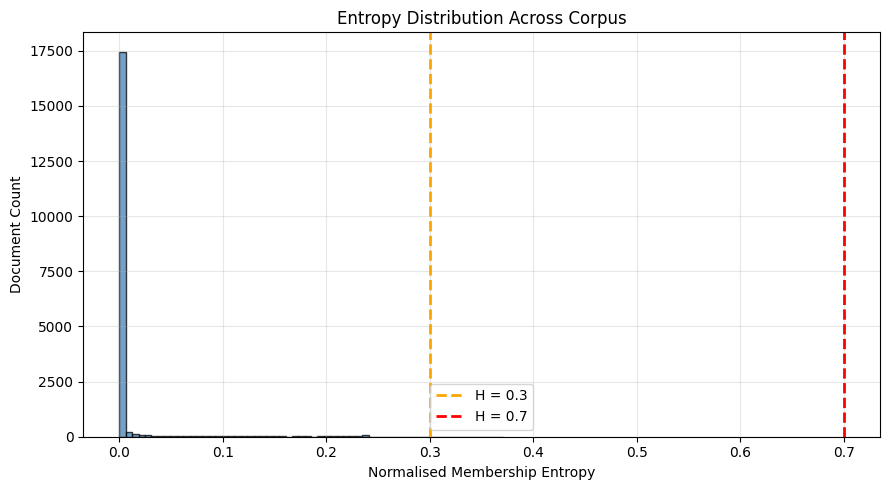

H < 0.3  (confident):    18732  (100.0%)
0.3-0.7  (ambiguous):        9  (0.0%)
H > 0.7  (boundary):         0  (0.0%)


In [9]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(entropies, bins=60, edgecolor='black', alpha=0.75, color='steelblue')
ax.axvline(0.3, color='orange', linestyle='--', linewidth=2, label='H = 0.3')
ax.axvline(0.7, color='red', linestyle='--', linewidth=2, label='H = 0.7')
ax.set_xlabel('Normalised Membership Entropy')
ax.set_ylabel('Document Count')
ax.set_title('Entropy Distribution Across Corpus')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Segment counts
low = int((entropies < 0.3).sum())
mid = int(((entropies >= 0.3) & (entropies <= 0.7)).sum())
high = int((entropies > 0.7).sum())
print(f'H < 0.3  (confident):    {low:5d}  ({low/N*100:.1f}%)')
print(f'0.3-0.7  (ambiguous):    {mid:5d}  ({mid/N*100:.1f}%)')
print(f'H > 0.7  (boundary):     {high:5d}  ({high/N*100:.1f}%)')